# Looped Sparse Chaos Compressor — Stage 1 Prototype

**Цель эксперимента (go/no-go test):** проверить, сохраняется ли 2-bit робастность chaos-активации при добавлении looped (recurrent-depth) блока.

**Гипотеза:** если рекуррентные итерации с weight sharing НЕ ломают bounded-распределение латента, то идея жизнеспособна → можно переходить к Stage 2 (Sparse MoE с chaos-экспертами).

**Сравнение:**
- Baseline V4 SAE (`T=0`, тест 19) — без loops
- V4 + Looped (`T=2, 4, 8`) — с weight-shared итерациями

**Ключевые метрики:**
1. Reconstruction loss (val MSE)
2. Dead latents
3. Деградация при 2/3/4/8-bit квантовании
4. Variance латента через итерации (стабильность)

**Стоп-критерий:** если 2-bit деградация `T>0` > 2× baseline (>17.4% vs 8.7%) → red flag, пересматриваем архитектуру.

**Данные:** GPT-2 small, layer 6, WikiText-2 (как в тесте 19).

In [1]:
import os
import json
from datetime import datetime
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import torch
from transformers import GPT2Model, GPT2Tokenizer
from datasets import load_dataset

print(f'TF: {tf.__version__}, torch: {torch.__version__}')
print(f'GPU (TF): {tf.config.list_physical_devices("GPU")}')

ARCH_DIR = Path('.').resolve()
CACHE_DIR = ARCH_DIR / 'cache'
CACHE_DIR.mkdir(exist_ok=True)
JSONS_DIR = ARCH_DIR.parent / 'jsons'

/Users/savenkovviktor/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


TF: 2.16.2, torch: 2.8.0
GPU (TF): [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Загрузка активаций GPT-2 (layer 6, WikiText-2)

Кэшируем в numpy, чтобы не перезапускать GPT-2 при повторных прогонах.

In [2]:
ACTIVATION_DIM = 768
TARGET_LAYER = 6
N_TEXTS = 500
MAX_LEN = 128

cache_file = CACHE_DIR / f'gpt2_layer{TARGET_LAYER}_n{N_TEXTS}.npy'

if cache_file.exists():
    print(f'Loading cached activations from {cache_file}')
    activations = np.load(cache_file)
else:
    print('Extracting GPT-2 activations...')
    tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
    model = GPT2Model.from_pretrained('gpt2')
    model.eval()
    tokenizer.pad_token = tokenizer.eos_token

    dataset = load_dataset('wikitext', 'wikitext-2-raw-v1', split='train')
    texts = [t for t in dataset['text'] if len(t) > 100][:N_TEXTS]

    acts = []
    with torch.no_grad():
        for i, text in enumerate(texts):
            inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=MAX_LEN)
            out = model(**inputs, output_hidden_states=True)
            h = out.hidden_states[TARGET_LAYER].squeeze(0).numpy()
            acts.append(h)
            if (i + 1) % 100 == 0:
                print(f'  {i+1}/{len(texts)}')

    activations = np.concatenate(acts, axis=0).astype('float32')
    np.save(cache_file, activations)
    del model, tokenizer

print(f'Activations: {activations.shape}')
print(f'Range: [{activations.min():.3f}, {activations.max():.3f}], mean={activations.mean():.3f}, std={activations.std():.3f}')

Extracting GPT-2 activations...
  100/500
  200/500
  300/500
  400/500
  500/500
Activations: (54573, 768)
Range: [-72.623, 2938.315], mean=0.033, std=10.727


In [3]:
act_mean = activations.mean(axis=0, keepdims=True)
act_std = activations.std(axis=0, keepdims=True) + 1e-8
activations_norm = ((activations - act_mean) / act_std).astype('float32')

np.random.seed(42)
idx = np.random.permutation(len(activations_norm))
split = int(len(idx) * 0.8)
x_train = activations_norm[idx[:split]]
x_test = activations_norm[idx[split:]]

print(f'Train: {x_train.shape}, Test: {x_test.shape}')

Train: (43658, 768), Test: (10915, 768)


## 2. Архитектурные компоненты

### 2.1. Chaos activation + KSparseLayer (из тестов 19-21)

Для LLM-активаций используем `a=1` (квази-линейный режим, оптимум из тестов 22-23).

In [4]:
def chaos_activation(x):
    return tf.sin(1.0 * x) + 0.5 * tf.tanh(4.0 * x)


class KSparseLayer(layers.Layer):
    def __init__(self, k=32, **kwargs):
        super().__init__(**kwargs)
        self.k = k

    def call(self, inputs, training=None):
        latent_dim = tf.shape(inputs)[1]
        _, indices = tf.nn.top_k(tf.abs(inputs), k=self.k, sorted=False)
        mask = tf.reduce_sum(tf.one_hot(indices, latent_dim, dtype=inputs.dtype), axis=1)
        return inputs * mask

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'k': self.k})
        return cfg

### 2.2. LoopedBlock — новый компонент

Идея: после encoder применяем один и тот же блок `T` раз (weight sharing, как в Universal Transformer). Каждая итерация:

1. Dense (shared weights)
2. Chaos activation
3. Residual update: `z_{t+1} = z_t + delta`
4. KSparse (повторный Top-K)

Residual нужен, чтобы латент не коллапсировал через много итераций. KSparse после каждого шага удерживает разреженность.

In [5]:
class LoopedBlock(layers.Layer):
    """Recurrent-depth блок: T weight-shared итераций рефинирования латента."""

    def __init__(self, latent_dim, k_active, T=4, use_residual=True, **kwargs):
        super().__init__(**kwargs)
        self.latent_dim = latent_dim
        self.k_active = k_active
        self.T = T
        self.use_residual = use_residual
        self.dense = layers.Dense(latent_dim, name='loop_dense')
        self.ksparse = KSparseLayer(k=k_active, name='loop_ksparse')

    def call(self, inputs, training=None, return_trajectory=False):
        z = inputs
        traj = [z] if return_trajectory else None
        for _ in range(self.T):
            delta = chaos_activation(self.dense(z))
            z = z + delta if self.use_residual else delta
            z = self.ksparse(z)
            if return_trajectory:
                traj.append(z)
        if return_trajectory:
            return z, traj
        return z

    def get_config(self):
        cfg = super().get_config()
        cfg.update({
            'latent_dim': self.latent_dim,
            'k_active': self.k_active,
            'T': self.T,
            'use_residual': self.use_residual,
        })
        return cfg

In [6]:
def build_looped_sae(input_dim, latent_dim, k_active, T=0, use_chaos=True):
    """SAE с опциональным looped refinement блоком.

    T=0 → базовый V4 (идентичен test_19).
    T>0 → после initial k-sparse применяем LoopedBlock.
    """
    inp = keras.Input(shape=(input_dim,))

    x = layers.Dense(latent_dim, name='latent_pre')(inp)
    x = layers.Activation(chaos_activation)(x) if use_chaos else layers.Activation('relu')(x)

    z0 = KSparseLayer(k=k_active, name='latent_ksparse_init')(x)

    if T > 0:
        z = LoopedBlock(latent_dim, k_active, T=T, name='looped_block')(z0)
    else:
        z = z0

    encoder = keras.Model(inp, z, name='encoder')
    decoded = layers.Dense(input_dim, name='decoder')(z)
    ae = keras.Model(inp, decoded)
    ae.compile(optimizer='adam', loss='mse')
    return ae, encoder

## 3. Квантование латента (min-max, per-sample)

Идентично тесту 21: квантуем только ненулевые (TopK-выжившие) значения, bit ∈ {2, 3, 4, 6, 8}.

In [7]:
def quantize_latent(latents, bits):
    """Min-max квантование ненулевых элементов каждого сэмпла до bits разрядов."""
    q = np.zeros_like(latents)
    levels = 2 ** bits - 1
    for i in range(latents.shape[0]):
        nz = np.where(np.abs(latents[i]) > 1e-10)[0]
        if len(nz) == 0:
            continue
        vals = latents[i, nz]
        vmin, vmax = vals.min(), vals.max()
        if vmax - vmin < 1e-10:
            q[i, nz] = vals
            continue
        norm = (vals - vmin) / (vmax - vmin)
        qn = np.round(norm * levels) / levels
        q[i, nz] = qn * (vmax - vmin) + vmin
    return q


def build_decoder_only(ae, latent_dim):
    """Выделяет decoder из обученного AE для прогона квантованных латентов."""
    dec_in = keras.Input(shape=(latent_dim,))
    # decoder в нашем SAE — один Dense слой
    for layer in ae.layers:
        if layer.name == 'decoder':
            out = layer(dec_in)
            return keras.Model(dec_in, out)
    raise RuntimeError('decoder layer not found')

## 4. Training + evaluation loop

In [8]:
NUM_RUNS = 3
EPOCHS = 8
BATCH_SIZE = 256
INPUT_DIM = ACTIVATION_DIM  # 768
LATENT_DIM = INPUT_DIM * 4  # 3072
K_ACTIVE = LATENT_DIM // 10  # 307
BITS_SWEEP = [2, 3, 4, 6, 8]
T_SWEEP = [0, 2, 4, 8]

print(f'Config: input={INPUT_DIM}, latent={LATENT_DIM}, K={K_ACTIVE}')
print(f'Sparsity: {(1 - K_ACTIVE/LATENT_DIM)*100:.0f}% | runs={NUM_RUNS} | epochs={EPOCHS}')
print(f'T sweep: {T_SWEEP} | bits sweep: {BITS_SWEEP}')

Config: input=768, latent=3072, K=307
Sparsity: 90% | runs=3 | epochs=8
T sweep: [0, 2, 4, 8] | bits sweep: [2, 3, 4, 6, 8]


In [9]:
def evaluate_config(T, run, verbose=False):
    np.random.seed(run)
    tf.random.set_seed(run)

    ae, enc = build_looped_sae(INPUT_DIM, LATENT_DIM, K_ACTIVE, T=T, use_chaos=True)
    params = ae.count_params()

    hist = ae.fit(x_train, x_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
                  validation_data=(x_test, x_test), verbose=0)
    val_loss = float(hist.history['val_loss'][-1])

    latents = enc.predict(x_test, batch_size=512, verbose=0)
    dead = int(np.sum(np.all(np.abs(latents) < 1e-6, axis=0)))
    lat_var = float(latents.var())
    nonzero_vals = latents[np.abs(latents) > 1e-10]
    lat_range = [float(nonzero_vals.min()), float(nonzero_vals.max())] if nonzero_vals.size else [0.0, 0.0]

    decoder = build_decoder_only(ae, LATENT_DIM)
    quant = {}
    for bits in BITS_SWEEP:
        q_lat = quantize_latent(latents, bits)
        q_rec = decoder.predict(q_lat, batch_size=512, verbose=0)
        q_loss = float(np.mean((x_test - q_rec) ** 2))
        quant[bits] = q_loss

    result = {
        'T': T, 'run': run, 'params': params,
        'val_loss': val_loss, 'dead': dead,
        'dead_pct': dead / LATENT_DIM * 100,
        'lat_var': lat_var, 'lat_range': lat_range,
        'quant': quant,
    }

    if verbose:
        deg2 = (quant[2] - val_loss) / val_loss * 100
        print(f'  T={T} run={run}: loss={val_loss:.4f} dead={dead} '
              f'var={lat_var:.4f} range={lat_range[0]:.2f}..{lat_range[1]:.2f} '
              f'2-bit deg={deg2:+.1f}%')

    del ae, enc, decoder
    keras.backend.clear_session()
    return result

## 5. Главный эксперимент

T ∈ {0, 2, 4, 8} × 3 seed × 5 bit-depths. Примерно 12 тренировок.

In [10]:
results = {T: [] for T in T_SWEEP}

for T in T_SWEEP:
    print(f'\n{"="*60}\n  T = {T} (baseline V4)' if T == 0 else f'\n{"="*60}\n  T = {T} (Looped)')
    print('='*60)
    for run in range(NUM_RUNS):
        r = evaluate_config(T, run, verbose=True)
        results[T].append(r)

print('\nAll configurations done.')


  T = 0 (baseline V4)


2026-04-23 19:04:12.147306: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-04-23 19:04:12.147350: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2026-04-23 19:04:12.147353: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.00 GB
2026-04-23 19:04:12.147521: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-23 19:04:12.147533: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-04-23 19:04:12.482803: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


  T=0 run=0: loss=0.1687 dead=0 var=0.1006 range=-1.50..1.50 2-bit deg=+10.2%
  T=0 run=1: loss=0.1685 dead=0 var=0.1008 range=-1.50..1.50 2-bit deg=+10.3%
  T=0 run=2: loss=0.1690 dead=0 var=0.1008 range=-1.50..1.50 2-bit deg=+10.3%

  T = 2 (Looped)
  T=2 run=0: loss=0.3352 dead=0 var=0.2132 range=-4.49..4.49 2-bit deg=+15.4%
  T=2 run=1: loss=0.3354 dead=0 var=0.2123 range=-4.49..4.48 2-bit deg=+15.6%
  T=2 run=2: loss=0.3351 dead=0 var=0.2128 range=-4.48..4.48 2-bit deg=+15.9%

  T = 4 (Looped)
  T=4 run=0: loss=0.5492 dead=0 var=0.2688 range=-7.22..7.01 2-bit deg=+11.7%
  T=4 run=1: loss=0.5483 dead=0 var=0.2690 range=-7.38..7.00 2-bit deg=+11.0%
  T=4 run=2: loss=0.5506 dead=0 var=0.2641 range=-6.88..6.94 2-bit deg=+11.3%

  T = 8 (Looped)
  T=8 run=0: loss=0.5428 dead=0 var=4.1743 range=-13.46..13.46 2-bit deg=+6.6%
  T=8 run=1: loss=0.5417 dead=0 var=4.1370 range=-13.47..13.49 2-bit deg=+6.8%
  T=8 run=2: loss=0.5438 dead=0 var=4.2622 range=-13.46..13.47 2-bit deg=+6.4%

All co

## 6. Сводная таблица + go/no-go верификация

In [11]:
def agg(runs, key):
    vals = np.array([r[key] for r in runs])
    return vals.mean(), vals.std()


header = f'{"T":>3} {"val_loss":>14} {"dead_%":>10} {"lat_var":>10} {"range":>18} '
header += ' '.join([f'{b}bit_deg%'.rjust(10) for b in BITS_SWEEP])
print(header)
print('-' * len(header))

summary = {}
for T in T_SWEEP:
    runs = results[T]
    vl_m, vl_s = agg(runs, 'val_loss')
    dp_m, _ = agg(runs, 'dead_pct')
    lv_m, _ = agg(runs, 'lat_var')
    rng_lo = np.mean([r['lat_range'][0] for r in runs])
    rng_hi = np.mean([r['lat_range'][1] for r in runs])

    deg_row = []
    for b in BITS_SWEEP:
        ql = np.mean([r['quant'][b] for r in runs])
        deg = (ql - vl_m) / vl_m * 100
        deg_row.append(deg)

    summary[T] = {'val_loss': (vl_m, vl_s), 'dead_pct': dp_m, 'lat_var': lv_m,
                  'range': (rng_lo, rng_hi), 'deg': dict(zip(BITS_SWEEP, deg_row))}

    deg_str = ' '.join([f'{d:+9.1f}' for d in deg_row])
    print(f'{T:>3} {vl_m:>7.4f}±{vl_s:.4f} {dp_m:>9.1f}% {lv_m:>10.4f} '
          f'[{rng_lo:>+5.2f},{rng_hi:>+5.2f}] {deg_str}')

  T       val_loss     dead_%    lat_var              range  2bit_deg%  3bit_deg%  4bit_deg%  6bit_deg%  8bit_deg%
------------------------------------------------------------------------------------------------------------------
  0  0.1687±0.0002       0.0%     0.1007 [-1.50,+1.50]     +10.3      +2.3      +0.3      +0.0      +0.0
  2  0.3352±0.0001       0.0%     0.2128 [-4.49,+4.49]     +15.6      +0.1      +0.5      +0.0      +0.0
  4  0.5494±0.0010       0.0%     0.2673 [-7.16,+6.98]     +11.3      +0.3      +0.2      +0.0      +0.0
  8  0.5428±0.0009       0.0%     4.1911 [-13.46,+13.47]      +6.6      +1.7      +0.4      +0.0      +0.0


In [12]:
# GO / NO-GO VERDICT
baseline_deg2 = summary[0]['deg'][2]
print(f'Baseline (T=0) 2-bit degradation: {baseline_deg2:+.1f}%')
print(f'Stop-criterion threshold: {2 * baseline_deg2:.1f}% (2x baseline)\n')

verdicts = {}
for T in T_SWEEP[1:]:
    d2 = summary[T]['deg'][2]
    if d2 <= 1.5 * baseline_deg2:
        verdict, tag = 'GO', '[+]'
    elif d2 <= 2.0 * baseline_deg2:
        verdict, tag = 'YELLOW', '[~]'
    else:
        verdict, tag = 'NO-GO', '[-]'
    verdicts[T] = verdict
    print(f'  T={T}: 2-bit deg={d2:+.1f}% → {tag} {verdict}')

print()
print('Дополнительные критерии:')
for T in T_SWEEP:
    dp = summary[T]['dead_pct']
    rng = summary[T]['range']
    bounded = max(abs(rng[0]), abs(rng[1])) < 5.0
    print(f'  T={T}: dead={dp:.1f}% | range=[{rng[0]:+.2f},{rng[1]:+.2f}] | '
          f'bounded={"YES" if bounded else "NO"}')

Baseline (T=0) 2-bit degradation: +10.3%
Stop-criterion threshold: 20.5% (2x baseline)

  T=2: 2-bit deg=+15.6% → [~] YELLOW
  T=4: 2-bit deg=+11.3% → [+] GO
  T=8: 2-bit deg=+6.6% → [+] GO

Дополнительные критерии:
  T=0: dead=0.0% | range=[-1.50,+1.50] | bounded=YES
  T=2: dead=0.0% | range=[-4.49,+4.49] | bounded=YES
  T=4: dead=0.0% | range=[-7.16,+6.98] | bounded=NO
  T=8: dead=0.0% | range=[-13.46,+13.47] | bounded=NO


## 7. Визуализация

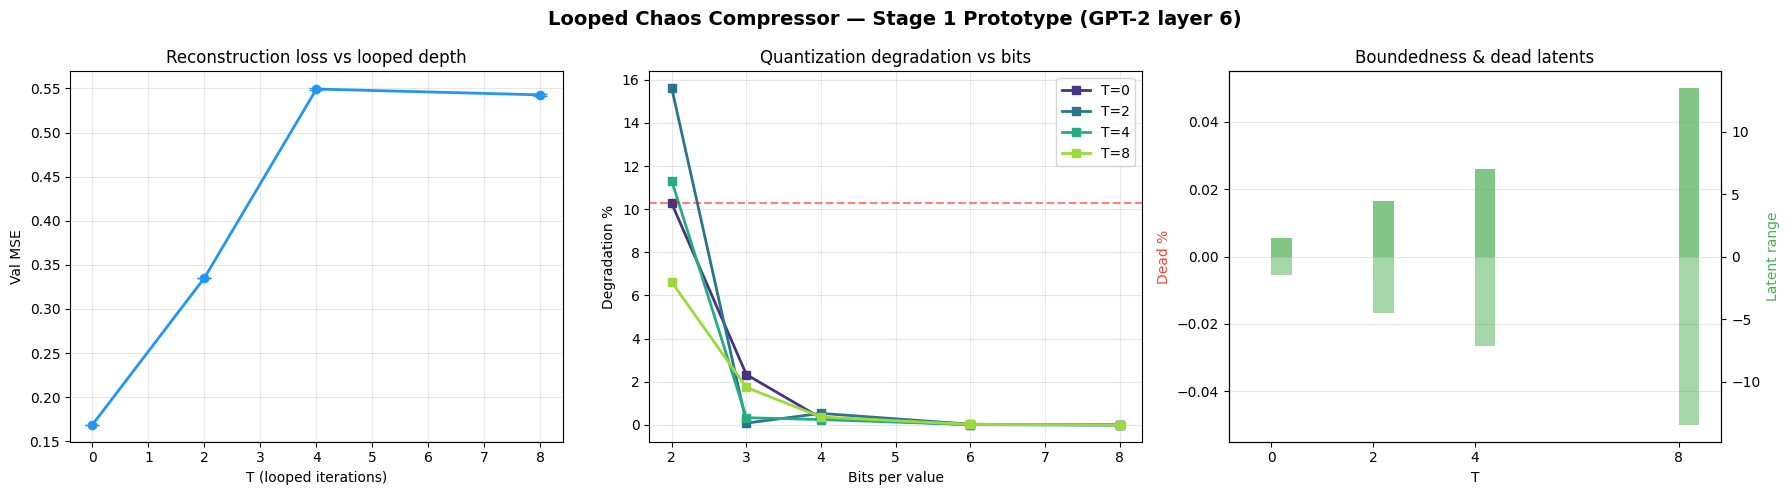

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Val loss vs T
vls = [summary[T]['val_loss'][0] for T in T_SWEEP]
vle = [summary[T]['val_loss'][1] for T in T_SWEEP]
axes[0].errorbar(T_SWEEP, vls, yerr=vle, marker='o', capsize=5, color='#2196F3', linewidth=2)
axes[0].set_xlabel('T (looped iterations)')
axes[0].set_ylabel('Val MSE')
axes[0].set_title('Reconstruction loss vs looped depth')
axes[0].grid(True, alpha=0.3)

# (b) RD-curve: degradation vs bits per T
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(T_SWEEP)))
for T, c in zip(T_SWEEP, colors):
    degs = [summary[T]['deg'][b] for b in BITS_SWEEP]
    axes[1].plot(BITS_SWEEP, degs, marker='s', label=f'T={T}', color=c, linewidth=2)
axes[1].set_xlabel('Bits per value')
axes[1].set_ylabel('Degradation %')
axes[1].set_title('Quantization degradation vs bits')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=baseline_deg2, color='red', linestyle='--', alpha=0.5,
                label=f'Baseline 2-bit ({baseline_deg2:+.1f}%)')

# (c) Dead % и latent range vs T
dps = [summary[T]['dead_pct'] for T in T_SWEEP]
axes[2].bar([t - 0.2 for t in T_SWEEP], dps, width=0.4, color='#F44336', label='Dead %', alpha=0.7)
ax2 = axes[2].twinx()
rng_hi = [summary[T]['range'][1] for T in T_SWEEP]
rng_lo = [summary[T]['range'][0] for T in T_SWEEP]
ax2.bar([t + 0.2 for t in T_SWEEP], rng_hi, width=0.4, color='#4CAF50', alpha=0.7, label='max |latent|')
ax2.bar([t + 0.2 for t in T_SWEEP], rng_lo, width=0.4, color='#4CAF50', alpha=0.5)
axes[2].set_xlabel('T')
axes[2].set_ylabel('Dead %', color='#F44336')
ax2.set_ylabel('Latent range', color='#4CAF50')
axes[2].set_title('Boundedness & dead latents')
axes[2].set_xticks(T_SWEEP)
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle('Looped Chaos Compressor — Stage 1 Prototype (GPT-2 layer 6)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(ARCH_DIR / 'looped_prototype_summary.png', dpi=120, bbox_inches='tight')
plt.show()

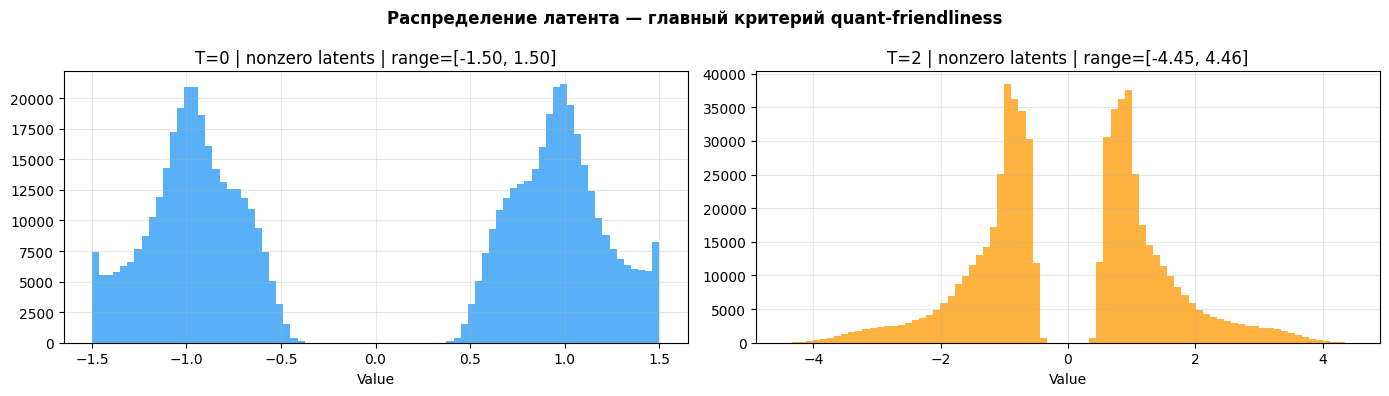

In [14]:
# Распределение латентных значений для T=0 vs лучшего T>0
best_T = min([T for T in T_SWEEP if T > 0], key=lambda T: summary[T]['val_loss'][0])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, T in zip(axes, [0, best_T]):
    np.random.seed(0)
    tf.random.set_seed(0)
    ae, enc = build_looped_sae(INPUT_DIM, LATENT_DIM, K_ACTIVE, T=T, use_chaos=True)
    ae.fit(x_train, x_train, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)
    lat = enc.predict(x_test[:2000], verbose=0)
    nz = lat[np.abs(lat) > 1e-10]
    ax.hist(nz, bins=80, color='#2196F3' if T == 0 else '#FF9800', alpha=0.75)
    ax.set_title(f'T={T} | nonzero latents | range=[{nz.min():.2f}, {nz.max():.2f}]')
    ax.set_xlabel('Value')
    ax.grid(True, alpha=0.3)
    del ae, enc
    keras.backend.clear_session()

plt.suptitle('Распределение латента — главный критерий quant-friendliness', fontweight='bold')
plt.tight_layout()
plt.savefig(ARCH_DIR / 'looped_latent_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Сохранение результатов

In [15]:
ts = datetime.now().strftime('%Y%m%d_%H%M%S')
out = {
    'experiment': 'looped_chaos_prototype_stage1',
    'timestamp': ts,
    'config': {
        'input_dim': INPUT_DIM, 'latent_dim': LATENT_DIM, 'k_active': K_ACTIVE,
        'T_sweep': T_SWEEP, 'bits_sweep': BITS_SWEEP,
        'num_runs': NUM_RUNS, 'epochs': EPOCHS,
        'target_layer': TARGET_LAYER, 'activation_dim': ACTIVATION_DIM,
    },
    'results': {str(T): results[T] for T in T_SWEEP},
    'summary': {str(T): {
        'val_loss_mean': summary[T]['val_loss'][0],
        'val_loss_std': summary[T]['val_loss'][1],
        'dead_pct': summary[T]['dead_pct'],
        'lat_var': summary[T]['lat_var'],
        'lat_range': summary[T]['range'],
        'degradation': summary[T]['deg'],
    } for T in T_SWEEP},
    'verdicts': {str(T): verdicts.get(T, 'BASELINE') for T in T_SWEEP},
}

out_file = JSONS_DIR / f'looped_chaos_stage1_{ts}.json'
with open(out_file, 'w') as f:
    json.dump(out, f, indent=2, default=float)
print(f'Saved: {out_file}')

Saved: /Users/savenkovviktor/Documents/GitHub/k-sparse-chaos-autoencoder/jsons/looped_chaos_stage1_20260423_193809.json


## 9. Вердикт

**Что смотрим:**

1. **2-bit деградация для T>0** — ключевой критерий. Если остаётся < 1.5× baseline (< 13%) → GO на Stage 2 (MoE).
2. **Bounded range** — сохраняется ли `|z| < 5` при T=4, 8? Если выходит за границы → Residual ломает bounded prior.
3. **Dead %** — если Looped вводит dead latents → слои коллапсируют, нужна другая архитектура.
4. **Val loss улучшается или деградирует с T** — если loss падает, значит loops полезны; если растёт → weight sharing мешает.

**План действий:**

- **Все T = GO** → переходим к Stage 2: `02_looped_moe_chaos.ipynb` (Sparse MoE с chaos-экспертами)
- **Все T = NO-GO** → Residual ломает bounded prior. Варианты: (а) добавить tanh-gate на delta, (б) нормализация после loops, (в) другая recurrent-схема (gated update как в GRU)
- **Частичный GO** → используем только те T, где работает (вероятно малые T=2)

Все числа сохраняются в [`../jsons/looped_chaos_stage1_*.json`](../jsons/) для сравнения между прогонами.